<a href="https://colab.research.google.com/github/BBotond03/MTDK_2026/blob/main/Visualisation_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generálok egy 10 másodperces, ~5 Hz-es organikus tremor (remegés) adatsort...



--- 3D FREKVENCIAANALÍZIS (FFT) ---


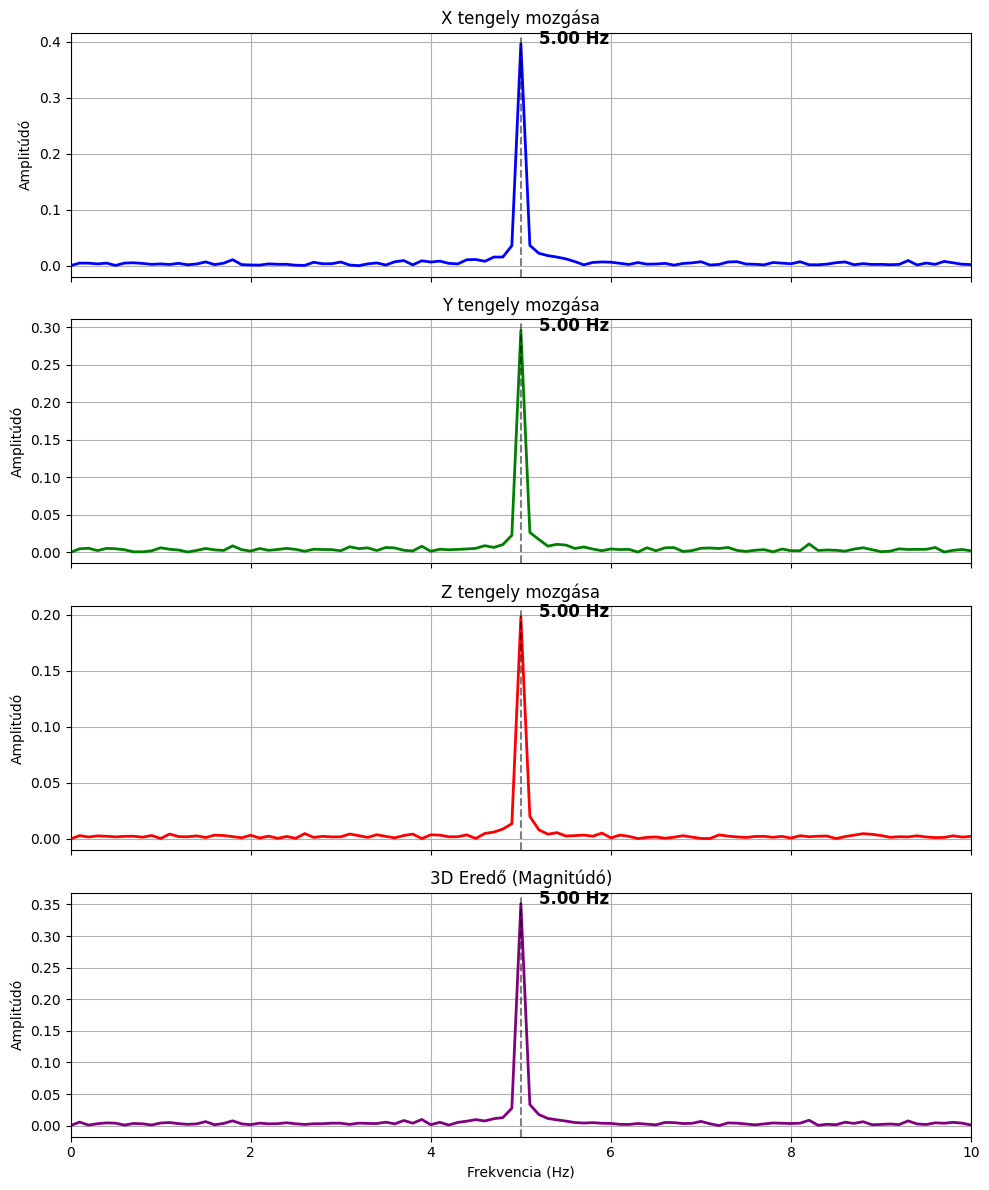

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import scipy.fftpack
import scipy.signal

# ==========================================
# 1. PARKINSON-TREMOR ADATOK GENERÁLÁSA
# ==========================================
pontok_szama = 600
fps = 60  # Magasabb FPS kell a gyors (5 Hz) rezgés szép megjelenítéséhez
dt = 1.0 / fps
t = np.linspace(0, pontok_szama * dt, pontok_szama)

print("Generálok egy 10 másodperces, ~5 Hz-es organikus tremor (remegés) adatsort...")

# Frekvencia beállítása (Parkinson tipikusan 4-6 Hz)
f_tremor = 5.0

# Biológiai zaj (hogy ne legyen tökéletesen gépies a szinusz hullám)
zaj_x = np.random.normal(0, 0.05, pontok_szama)
zaj_y = np.random.normal(0, 0.05, pontok_szama)
zaj_z = np.random.normal(0, 0.03, pontok_szama)

# A kéz pozíciója (egy fix pontban tartják, pl. a 10, 10, 10 koordinátán)
# Ezen a ponton remeg a kéz különböző fázisokban a 3 tengelyen
x_data = 10.0 + 0.4 * np.sin(2 * np.pi * f_tremor * t) + zaj_x
y_data = 10.0 + 0.3 * np.sin(2 * np.pi * f_tremor * t + 1.2) + zaj_y # Fáziseltolás
z_data = 10.0 + 0.2 * np.cos(2 * np.pi * f_tremor * t + 0.5) + zaj_z

# Irányvektor (a henger/óra dőlése is remeg a csukló mozgása miatt)
vx_data = 0.1 * np.sin(2 * np.pi * f_tremor * t)
vy_data = 0.1 * np.cos(2 * np.pi * f_tremor * t)
vz_data = np.ones_like(t) # Főleg felfelé néz

# ==========================================
# 2. GRAFIKA ÉS KORONG ELŐKÉSZÍTÉSE
# ==========================================
sugar_max = 0.8
r = np.linspace(0, sugar_max, 5)
theta = np.linspace(0, 2*np.pi, 20)
r_grid, theta_grid = np.meshgrid(r, theta)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Tengelyek fixálása a kéz köré (szorosabb nézet, hogy lássuk a remegést)
ax.set_xlim(8.5, 11.5)
ax.set_ylim(8.5, 11.5)
ax.set_zlim(8.5, 11.5)
ax.set_xlabel('X tengely')
ax.set_ylabel('Y tengely')
ax.set_zlabel('Z tengely')

utvonal_vonal, = ax.plot([], [], [], color='blue', alpha=0.3, linewidth=1)
korong_tarolo = [None]

# ==========================================
# 3. AZ OPTIMALIZÁLT UPDATE FÜGGVÉNY
# ==========================================
def update(frame):
    if korong_tarolo[0] is not None:
        korong_tarolo[0].remove()

    # Útvonal frissítése (hogy lássuk a remegés mintáját)
    utvonal_vonal.set_data(x_data[:frame], y_data[:frame])
    utvonal_vonal.set_3d_properties(z_data[:frame])

    cx, cy, cz = x_data[frame], y_data[frame], z_data[frame]
    vx, vy, vz = vx_data[frame], vy_data[frame], vz_data[frame]

    n = np.array([vx, vy, vz], dtype=float)
    n_norm = np.linalg.norm(n)
    if n_norm > 0: n /= n_norm
    else: n = np.array([0.0, 0.0, 1.0])

    u = np.array([1.0, 0.0, 0.0])
    if abs(n[0]) > 0.9: u = np.array([0.0, 1.0, 0.0])

    v1 = np.cross(n, u)
    v1 /= np.linalg.norm(v1)
    v2 = np.cross(n, v1)

    X = cx + r_grid * np.cos(theta_grid) * v1[0] + r_grid * np.sin(theta_grid) * v2[0]
    Y = cy + r_grid * np.cos(theta_grid) * v1[1] + r_grid * np.sin(theta_grid) * v2[1]
    Z = cz + r_grid * np.cos(theta_grid) * v1[2] + r_grid * np.sin(theta_grid) * v2[2]

    korong_tarolo[0] = ax.plot_surface(X, Y, Z, color='orange', alpha=0.9, edgecolor='none')
    return utvonal_vonal,

# ==========================================
# 4. RENDERELÉS
# ==========================================
ani = FuncAnimation(fig, update, frames=len(x_data), interval=dt*1000, blit=False)
plt.close(fig)
display(HTML(ani.to_html5_video()))

# ==========================================
# 5. 3D FREKVENCIAANALÍZIS (X, Y, Z + EREDŐ)
# ==========================================
print("\n--- 3D FREKVENCIAANALÍZIS (FFT) ---")

# Térbeli eredő (magnitúdó) kiszámítása
eredo_data = np.sqrt(x_data**2 + y_data**2 + z_data**2)

N = len(x_data)
xf = scipy.fftpack.fftfreq(N, dt)[:N//2]

# 4 részre osztott grafikon (X, Y, Z és Eredő)
fig_fft, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

tengelyek_adatai = [
    ('X tengely mozgása', x_data, 'blue'),
    ('Y tengely mozgása', y_data, 'green'),
    ('Z tengely mozgása', z_data, 'red'),
    ('3D Eredő (Magnitúdó)', eredo_data, 'purple')
]

for i, (nev, adat, szin) in enumerate(tengelyek_adatai):
    # Trendeltávolítás (Középpontra húzzuk az adatokat)
    tisztitott_adat = scipy.signal.detrend(adat)

    yf = scipy.fftpack.fft(tisztitott_adat)
    amplitudo = 2.0/N * np.abs(yf[0:N//2])

    csucs_index = np.argmax(amplitudo)
    dominans_frekvencia = xf[csucs_index]
    max_amp = amplitudo[csucs_index]

    axs[i].plot(xf, amplitudo, color=szin, linewidth=2)

    # 0.1-es küszöb, hogy az apró zajokat ne vegye domináns csúcsnak
    if max_amp > 0.02:
        axs[i].axvline(x=dominans_frekvencia, color='black', linestyle='--', alpha=0.5)
        axs[i].text(dominans_frekvencia + 0.2, max_amp, f'{dominans_frekvencia:.2f} Hz', fontsize=12, fontweight='bold')

    axs[i].set_title(nev)
    axs[i].set_ylabel('Amplitúdó')
    axs[i].grid(True)

# Mivel a Parkinson tremor 4-6 Hz, elég 10 Hz-ig nézni a spektrumot
axs[3].set_xlabel('Frekvencia (Hz)')
axs[3].set_xlim(0, 10)
plt.tight_layout()
plt.show()